In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("heart.csv")
df

,37,M,ATA,130,283,0,ST,98,N,0.1,Up,0.2
0,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
1,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
2,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
3,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
4,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
910,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
911,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
912,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
913,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


## EDA


In [7]:
df.columns

Index(['37', 'M', 'ATA', '130', '283', '0', 'ST', '98', 'N', '0.1', 'Up',
       '0.2'],
      dtype='object')

In [8]:
df.shape

(915, 12)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 915 entries, 0 to 914
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   37      915 non-null    int64  
 1   M       915 non-null    object 
 2   ATA     915 non-null    object 
 3   130     915 non-null    int64  
 4   283     915 non-null    int64  
 5   0       915 non-null    int64  
 6   ST      915 non-null    object 
 7   98      915 non-null    int64  
 8   N       915 non-null    object 
 9   0.1     915 non-null    float64
 10  Up      915 non-null    object 
 11  0.2     915 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 85.9+ KB


In [11]:
df.describe()

,37,130,283,0,98,0.1,0.2
count,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000
mean,53.548634,132.360656,198.629508,0.233880,136.792350,0.889180,0.554098
std,9.420436,18.520111,109.485566,0.423528,25.435217,1.067504,0.497337
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,155.500000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [13]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='0.2'>

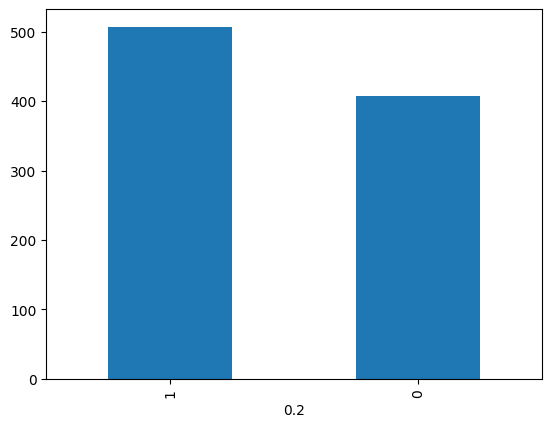

In [15]:
df['0.2'].value_counts().plot(kind='bar')

In [16]:
df.isnull().sum()

37     0
M      0
ATA    0
130    0
283    0
0      0
ST     0
98     0
N      0
0.1    0
Up     0
0.2    0
dtype: int64

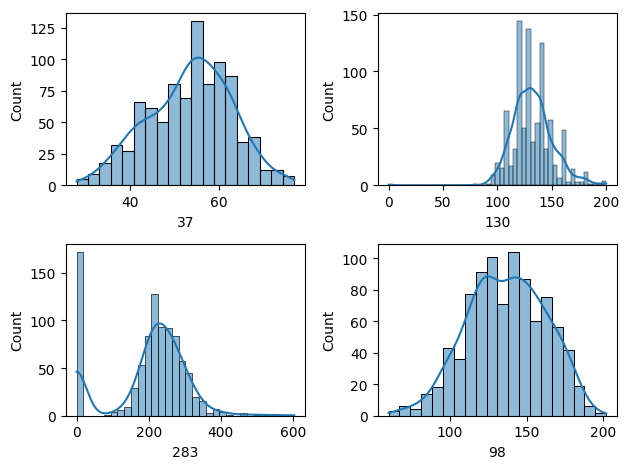

In [27]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)
plotting('37',1)
plotting('130',2)
plotting('283',3)
plotting('98',4)
plt.tight_layout()

In [29]:
cht = df.loc[df['0.1'] !=0 ,'0.1'].mean()

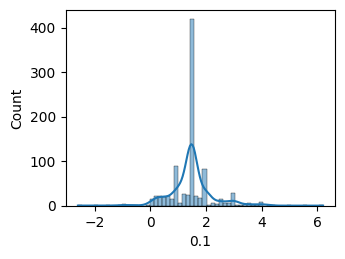

In [35]:
df['0.1']=df['0.1'].replace(0,cht)
df['0.1']=df['0.1'].round(2)
df['0.1']=df['0.1'].replace(0,cht)
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)
plotting('0.1',1)
plt.tight_layout()

<Axes: xlabel='M', ylabel='count'>

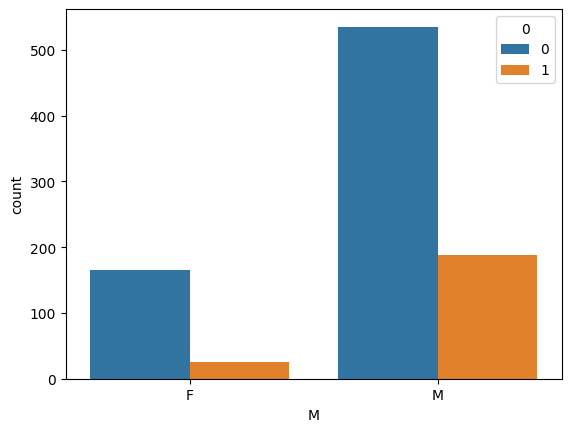

In [41]:
sns.countplot(x=df['M'],hue=df['0'])

<Axes: xlabel='ATA', ylabel='count'>

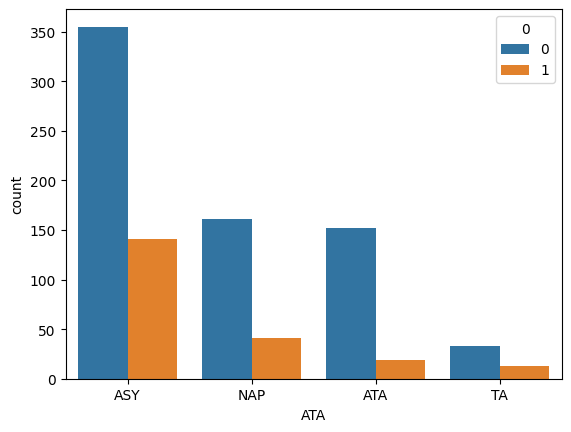

In [40]:
sns.countplot(x=df['ATA'],hue=df['0'])

<Axes: xlabel='0', ylabel='0.1'>

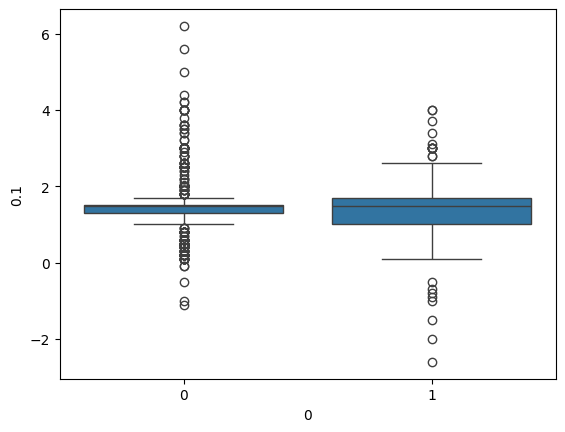

In [45]:
sns.boxplot(x= '0',y='0.1',data=df)

<Axes: >

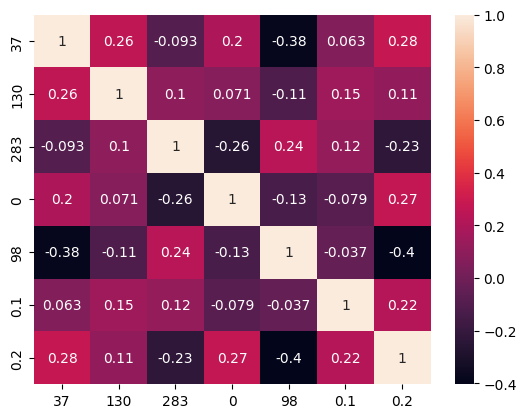

In [46]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [47]:
df_code =pd.get_dummies(df,drop_first=True)
df_code

,37,130,283,0,98,0.1,0.2,M_M,ATA_ATA,ATA_NAP,ATA_TA,ST_Normal,ST_ST,N_Y,Up_Flat,Up_Up
0,48,138,214,0,108,1.50,1,False,False,False,False,True,False,True,True,False
1,54,150,195,0,122,1.48,0,True,False,True,False,True,False,False,False,True
2,39,120,339,0,170,1.48,0,True,False,True,False,True,False,False,False,True
3,45,130,237,0,170,1.48,0,False,True,False,False,True,False,False,False,True
4,54,110,208,0,142,1.48,0,True,True,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,45,110,264,0,132,1.20,1,True,False,False,True,True,False,False,True,False
911,68,144,193,1,141,3.40,1,True,False,False,False,True,False,False,True,False
912,57,130,131,0,115,1.20,1,True,False,False,False,True,False,True,True,False
913,57,130,236,0,174,1.48,1,False,True,False,False,False,False,False,True,False


In [48]:
df_code =df_code.astype(int)

In [49]:
df_code

,37,130,283,0,98,0.1,0.2,M_M,ATA_ATA,ATA_NAP,ATA_TA,ST_Normal,ST_ST,N_Y,Up_Flat,Up_Up
0,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
1,54,150,195,0,122,1,0,1,0,1,0,1,0,0,0,1
2,39,120,339,0,170,1,0,1,0,1,0,1,0,0,0,1
3,45,130,237,0,170,1,0,0,1,0,0,1,0,0,0,1
4,54,110,208,0,142,1,0,1,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
911,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
912,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
913,57,130,236,0,174,1,1,0,1,0,0,0,0,0,1,0
